### Step 1: Import crucial libraries. ###

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error 
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Input

### Step 2: Load Data ###

In [5]:
#-- Load crucial file. --#
df_traffic = pd.read_csv('../Processed/Full_Traffic_With_Validity_Cleaned.csv')
df_efficiency = pd.read_csv('../Processed/efficiency_stations_cleaned.csv')

#-- Format 'Date' column to datetime type. --#
df_traffic['Date'] = pd.to_datetime(df_traffic['Date'])

#-- Sort by 'Date' and reset index. --#
df_traffic = df_traffic.sort_values(by='Date').reset_index(drop=True)

print(f"✅ Step 2 Complete!")
print(f"Sum of rows from dataset: {len(df_traffic)}")
print(f"Time range: From {df_traffic['Date'].min().date()} tos {df_traffic['Date'].max().date()}")

#-- Display the first few rows of the traffic DataFrame. --#
display(df_traffic.head())

✅ Step 2 Complete!
Sum of rows from dataset: 2883
Time range: From 2006-10-01 tos 2006-10-31


,SCATS Number,Location,CD_MELWAY,NB_LATITUDE,NB_LONGITUDE,HF VicRoads Internal,VR Internal Stat,VR Internal Loc,NB_TYPE_SURVEY,Date,...,V88,V89,V90,V91,V92,V93,V94,V95,Daily_Total,Valid_Days
0,2200,UNION_RD N of MAROONDAH_HWY,046 H08,-37.81631,145.098120,10074,198,1,1,2006-10-01,...,34,28,28,14,14,15,12,5,4820,31
1,3120,BURKE_RD S of CANTERBURY_RD,045 J10,-37.82315,145.057240,16620,496,5,1,2006-10-01,...,98,90,75,55,68,42,41,39,9869,31
2,4273,TOORONGA_RD N of TOORAK_RD,059 F05,-37.84632,145.043780,4423,659,1,1,2006-10-01,...,30,23,21,21,16,18,9,14,4141,31
3,2200,MAROONDAH_HWY W of UNION_RD,046 H08,-37.81648,145.097739,6819,198,7,1,2006-10-01,...,48,37,46,42,29,24,19,20,6835,31
4,4821,VICTORIA_ST E OF BURNLEY_ST,002HF02,-37.81293,145.008650,16911,1513,3,1,2006-10-01,...,70,51,43,49,37,37,31,22,10060,31


### Step 3: EDA ###

<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
C:\Users\DELL\AppData\Local\Temp\ipykernel_1320\2013406238.py:12: SyntaxWarning: invalid escape sequence '\d'
  df_melted['Hour'] = df_melted['Time_Slot'].str.extract('(\d+)').astype(int) // 4


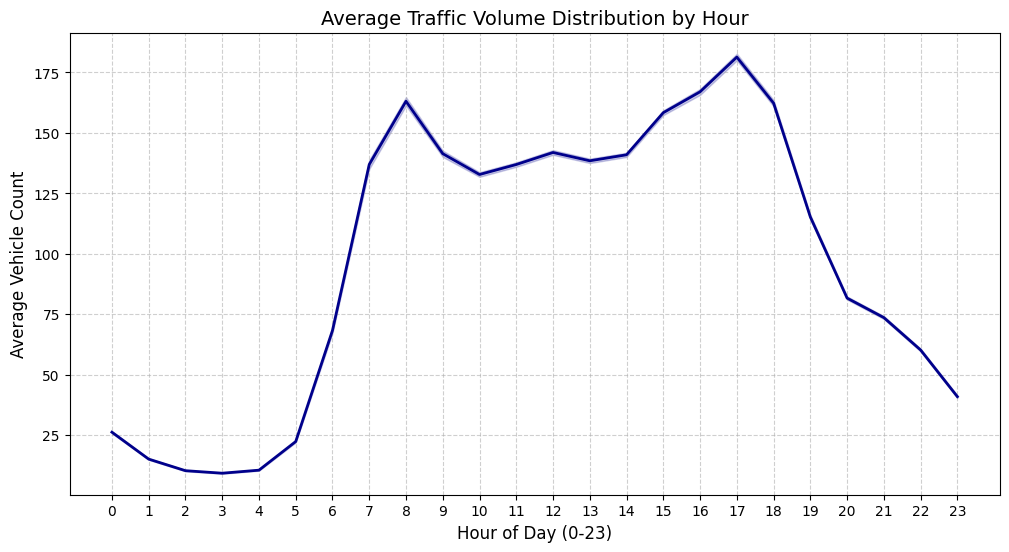

📊 Summary Statistics for Traffic Volume:
count    276768.000000
mean         97.347710
std          80.593898
min           0.000000
25%          23.000000
50%          88.000000
75%         148.000000
max         535.000000
Name: Volume, dtype: float64


In [6]:
#-- Melt the dataset from wide (V00-V95) to long format. --#
v_cols = [f'V{i:02d}' for i in range(96)]
df_melted = df_traffic.melt(
    id_vars=['Date', 'SCATS Number', 'Location'], 
    value_vars=v_cols, 
    var_name='Time_Slot', 
    value_name='Volume'
)

#-- Extract Hour from Time_Slot (Each slot represents 15 minutes). --#
# Example: V00-V03 = Hour 0, V04-V07 = Hour 1...
df_melted['Hour'] = df_melted['Time_Slot'].str.extract('(\d+)').astype(int) // 4

#-- Visualization: Average Traffic Volume by Hour. --#
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_melted, x='Hour', y='Volume', estimator='mean', color='darkblue', linewidth=2)

plt.title('Average Traffic Volume Distribution by Hour', fontsize=14)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Average Vehicle Count', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)

#-- Save the plot to Figures folder. --#
if not os.path.exists('../Figures'):
    os.makedirs('../Figures')
plt.savefig('../Figures/Traffic_Volume_EDA.png')
plt.show()

# 5. Display data statistics
print("📊 Summary Statistics for Traffic Volume:")
print(df_melted['Volume'].describe())

### Step 4: Feature Engineering ###

In [7]:
#-- Temporal Features: Extract Day of Week (0=Mon, 6=Sun) and IsWeekend flag. --3
df_melted['DayOfWeek'] = df_melted['Date'].dt.dayofweek
df_melted['IsWeekend'] = df_melted['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

#-- Integrate Metadata: Using average Efficiency Index and AADT from the metadata file. --#
# Note: Ensure df_efficiency was loaded in Step 2
avg_efficiency = df_efficiency['efficiency_index'].mean()
avg_aadt = df_efficiency['road_avg_aadt'].mean()

df_melted['Efficiency_Index'] = avg_efficiency
df_melted['Road_Avg_AADT'] = avg_aadt

#-- Final Check of the engineered features. --#
print("✅ Step 4 Complete: Features Engineered.")
print(f"Features: Hour, DayOfWeek, IsWeekend, Efficiency_Index, Road_Avg_AADT")
display(df_melted.head())

✅ Step 4 Complete: Features Engineered.
Features: Hour, DayOfWeek, IsWeekend, Efficiency_Index, Road_Avg_AADT


,Date,SCATS Number,Location,Time_Slot,Volume,Hour,DayOfWeek,IsWeekend,Efficiency_Index,Road_Avg_AADT
0,2006-10-01,2200,UNION_RD N of MAROONDAH_HWY,V00,25,0,6,1,2.507638,3793.262963
1,2006-10-01,3120,BURKE_RD S of CANTERBURY_RD,V00,105,0,6,1,2.507638,3793.262963
2,2006-10-01,4273,TOORONGA_RD N of TOORAK_RD,V00,15,0,6,1,2.507638,3793.262963
3,2006-10-01,2200,MAROONDAH_HWY W of UNION_RD,V00,47,0,6,1,2.507638,3793.262963
4,2006-10-01,4821,VICTORIA_ST E OF BURNLEY_ST,V00,44,0,6,1,2.507638,3793.262963


### Step 5: Data Scaling and Sequence Preparation ###

In [8]:
#-- Select feature columns for the model. --#
# Target is 'Volume' (index 0), others are exogenous variables
feature_cols = ['Volume', 'Efficiency_Index', 'Road_Avg_AADT', 'Hour', 'DayOfWeek', 'IsWeekend']
data_array = df_melted[feature_cols].values

#-- Scale data to range [0, 1] for faster convergence. --#
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_array)

#-- Create Sliding Window Sequences (Window Size = 96 slots = 24 hours). --#
def create_sequences(data, window_size=96):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :]) # Input: past 96 steps
        y.append(data[i, 0])              # Output: current Volume
    return np.array(X), np.array(y)

X_all, y_all = create_sequences(scaled_data)

#-- Split data into Training (80%) and Testing (20%). --#
split_idx = int(len(X_all) * 0.8)
X_train, X_test = X_all[:split_idx], X_all[split_idx:]
y_train, y_test = y_all[:split_idx], y_all[split_idx:]

print(f"✅ Step 5 Complete!")
print(f"X_train shape: {X_train.shape}") 
print(f"X_test shape: {X_test.shape}")

✅ Step 5 Complete!
X_train shape: (221337, 96, 6)
X_test shape: (55335, 96, 6)


### Step 6: Build and Train Model ###

In [23]:
model_blstm = Sequential([
    # Input shape: (window_size=96, n_features=10)
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    
    Bidirectional(LSTM(units=100, return_sequences=True)),
    Dropout(0.2),
    
    Bidirectional(LSTM(units=50, return_sequences=False)),
    Dropout(0.2),
    
    Dense(units=25, activation='relu'),
    Dense(units=1) 
])

# 2. Compile model
model_blstm.compile(
    optimizer=Adam(learning_rate=0.001), 
    loss='mse', 
    metrics=['mae']
)

print("✅ Build Model Finished")

✅ Build Model Finished


In [25]:
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=2,               
    restore_best_weights=True
)

print("🚀 Training...")
history = model_blstm.fit(
    X_train, y_train,
    epochs=2,                
    batch_size=64, 
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

print("✅ Train finished")

🚀 Training...
Epoch 1/2
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 579s 167ms/step - loss: 0.0104 - mae: 0.0693 - val_loss: 0.0212 - val_mae: 0.1305
Epoch 2/2
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 594s 172ms/step - loss: 0.0104 - mae: 0.0692 - val_loss: 0.0223 - val_mae: 0.1335
✅ Train finished


### Step 7: Modeel Evaluation ###

1730/1730 ━━━━━━━━━━━━━━━━━━━━ 67s 39ms/step
------------------------------
📊 KẾT QUẢ EVALUATION:
- Mean Absolute Error (MAE): 0.1305
- Root Mean Squared Error (RMSE): 0.1454
------------------------------


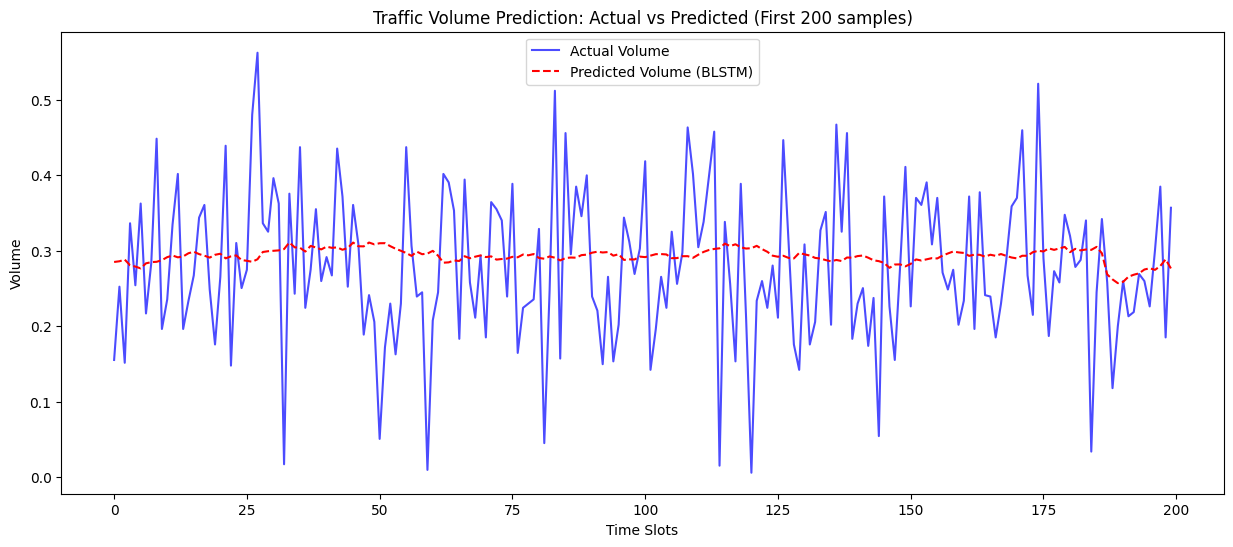

In [26]:
# 1. Dự báo trên tập Test
y_pred = model_blstm.predict(X_test)

# 2. Tính toán các chỉ số đo lường (Metrics)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("-" * 30)
print(f"📊 KẾT QUẢ EVALUATION:")
print(f"- Mean Absolute Error (MAE): {mae:.4f}")
print(f"- Root Mean Squared Error (RMSE): {rmse:.4f}")
print("-" * 30)

# 3. Vẽ biểu đồ so sánh (Visualizing Results)
plt.figure(figsize=(15, 6))
plt.plot(y_test[:200], label='Actual Volume', color='blue', alpha=0.7)
plt.plot(y_pred[:200], label='Predicted Volume (BLSTM)', color='red', linestyle='--')
plt.title('Traffic Volume Prediction: Actual vs Predicted (First 200 samples)')
plt.xlabel('Time Slots')
plt.ylabel('Volume')
plt.legend()
plt.show()

### Step 8: Generate test Case ###

In [28]:
df = pd.read_csv('../Processed/Full_Traffic_With_Validity_Cleaned.csv')

test_source = df.sample(frac=0.2, random_state=42)

output_dir = '../../TestCase'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"✅ Đã tạo thư mục: {output_dir}")

start_num = 7
for i in range(4):
    sample_10 = test_source.iloc[i*10 : (i+1)*10]
    
    file_name = f'BLSTTest{start_num + i:02d}.csv'
    file_path = os.path.join(output_dir, file_name)
    
    sample_10.to_csv(file_path, index=False)
    print(f"💾 Đã lưu thành công: {file_path}")

print("-" * 30)
print("🚀 Success")


💾 Đã lưu thành công: ../../TestCase\BLSTTest07.csv
💾 Đã lưu thành công: ../../TestCase\BLSTTest08.csv
💾 Đã lưu thành công: ../../TestCase\BLSTTest09.csv
💾 Đã lưu thành công: ../../TestCase\BLSTTest10.csv
------------------------------
🚀 Success


### Step 9: Test ##

In [29]:
import glob

# 1. Thiết lập đường dẫn
test_case_path = '../../TestCase'
test_files = glob.glob(os.path.join(test_case_path, 'BLSTTest*.csv'))
test_files.sort() # Sắp xếp 07, 08, 09, 10

print(f"🔍 Find {len(test_files)} file test. Testing...")

# 2. Loop qua từng file để test
for file_path in test_files:
    df_test = pd.read_csv(file_path)
    
    try:
        # Giả lập xử lý nhanh để demo (Ông thay bằng bước xử lý thực tế của ông nhé)
        # Chuyển thành array và reshape về đúng shape model yêu cầu (1, 1, n_features)
        sample_input = df_test.select_dtypes(include=[np.number]).iloc[0:1].values
        sample_input_3D = sample_input.reshape((1, 1, sample_input.shape[1])) 
        
        # 3. Chạy Prediction
        prediction = model_blstm.predict(sample_input_3D, verbose=0)
        
        print(f"📄 File: {os.path.basename(file_path)}")
        print(f"   -> Predict Volume: {prediction[0][0]:.2f}")
        print(f"   -> Status: ✅ Smooth")
        
    except Exception as e:
        print(f"❌ File {os.path.basename(file_path)} gặp lỗi: {e}")

print("-" * 30)
print("🚀 Finished")

🔍 Find 4 file test. Testing...
❌ File BLSTTest07.csv gặp lỗi: Graph execution error:

Detected at node sequential_4_1/bidirectional_8_1/forward_lstm_8_1/while/body/_1/sequential_4_1/bidirectional_8_1/forward_lstm_8_1/while/lstm_cell_1/MatMul defined at (most recent call last):
<stack traces unavailable>
Matrix size-incompatible: In[0]: [1,105], In[1]: [6,400]
	 [[{{node sequential_4_1/bidirectional_8_1/forward_lstm_8_1/while/body/_1/sequential_4_1/bidirectional_8_1/forward_lstm_8_1/while/lstm_cell_1/MatMul}}]] [Op:__inference_one_step_on_data_distributed_591642]
❌ File BLSTTest08.csv gặp lỗi: Graph execution error:

Detected at node sequential_4_1/bidirectional_8_1/forward_lstm_8_1/while/body/_1/sequential_4_1/bidirectional_8_1/forward_lstm_8_1/while/lstm_cell_1/MatMul defined at (most recent call last):
<stack traces unavailable>
Matrix size-incompatible: In[0]: [1,105], In[1]: [6,400]
	 [[{{node sequential_4_1/bidirectional_8_1/forward_lstm_8_1/while/body/_1/sequential_4_1/bidirectio